#### Identify features with higher correlations with target variable
The goal is to predict energy consumption of buildings, the target variable (y) is Electricity(kWh). This variable is a continuous numerical value. The features (X) input variables that influence energy consumption are: Floor area, building type, age of building, number of floors, etc. 

Use correlation matrix to provide insights into how different features relate to the target variable. We can infer:
Strongly correlated features (r > 0.7)
- SiteEnergyUseWN(kBtu): 0.85
- PropertyGFABuildings: 0.78
- SelfReportGFABuildings: 0.77
- PropertyGFATotal: 0.77

In [2]:
import pandas as pd
df = pd.read_csv("data/preprocessed_data.csv")

In [3]:
#compute correlation matrix
correlation_matrix = df.corr()

correlation_with_target = correlation_matrix["Electricity(kWh)"].sort_values(ascending=False)
print(correlation_with_target)

Electricity(kWh)                     1.000000
SiteEnergyUseWN(kBtu)                0.848481
PropertyGFABuildings                 0.776735
SelfReportGFABuildings               0.774715
PropertyGFATotal                     0.768484
SelfReportGFATotal                   0.764650
LargestPropertyUseTypeGFA            0.739758
TotalGHGEmissions                    0.662779
SelfReportParking                    0.411620
SourceEUI(kBtu/sf)                   0.397956
PropertyGFAParking                   0.389143
SiteEUIWN(kBtu/sf)                   0.343611
NumberofFloors                       0.333176
GHGEmissionsIntensity                0.170310
BuildingType_Nonresidential WA       0.147023
NumberofBuildings                    0.140531
BuildingType_NonResidential          0.105582
BuildingType_Multifamily HR (10+)    0.039828
BuildingType_Nonresidential COS      0.006676
DataYear                            -0.009457
Demolished                          -0.013269
BuildingType_SPS-District K-12    

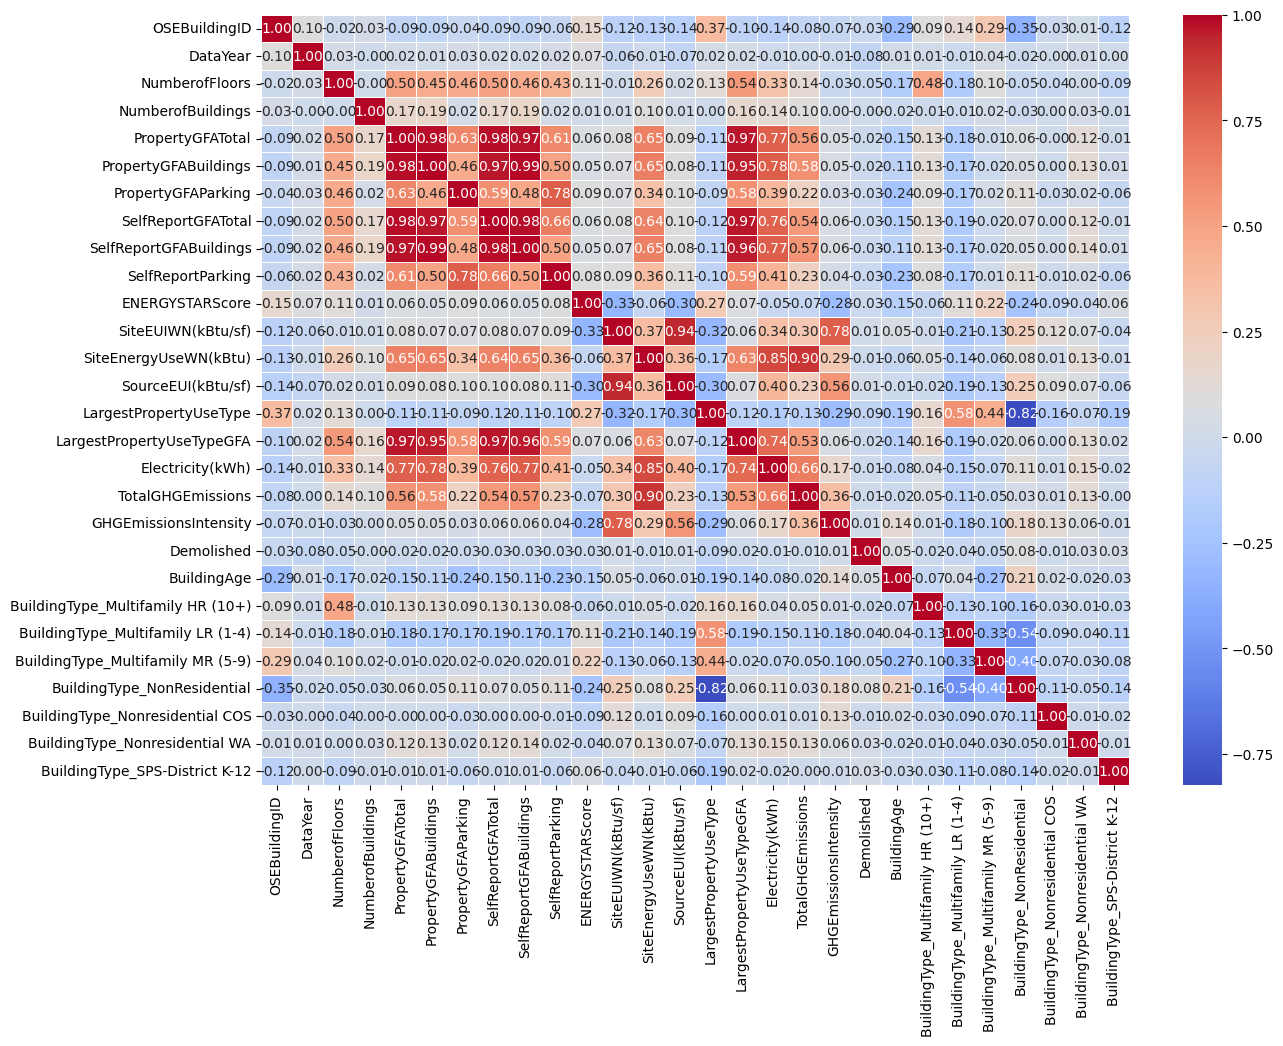

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

# generate correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.show()

corr_threshold = 0.2

selected_features = correlation_matrix["Electricity(kWh)"].abs()
selected_features = selected_features[selected_features > corr_threshold].index.tolist()
print(selected_features)

df = df[selected_features]

df.head()

### XGBOOST MODEL

We need to handle dataset with different categories the BuildingType fields. The dataset contains different building tyes:
['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Nonresidential WA', 'Multifamily HR (10+)']
each category might have different energy consumpption patterns.
Different categories have different relationships, training separate models for each category can help

In [5]:
# Identify building type categories
print(df.columns)

Index(['OSEBuildingID', 'DataYear', 'NumberofFloors', 'NumberofBuildings',
       'PropertyGFATotal', 'PropertyGFABuildings', 'PropertyGFAParking',
       'SelfReportGFATotal', 'SelfReportGFABuildings', 'SelfReportParking',
       'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)',
       'SourceEUI(kBtu/sf)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'Electricity(kWh)', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Demolished', 'BuildingAge',
       'BuildingType_Multifamily HR (10+)',
       'BuildingType_Multifamily LR (1-4)',
       'BuildingType_Multifamily MR (5-9)', 'BuildingType_NonResidential',
       'BuildingType_Nonresidential COS', 'BuildingType_Nonresidential WA',
       'BuildingType_SPS-District K-12'],
      dtype='object')


In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score



Training model for category: BuildingType_Multifamily HR (10+)
BuildingType_Multifamily HR (10+) model R2 score: 0.9831699411227609


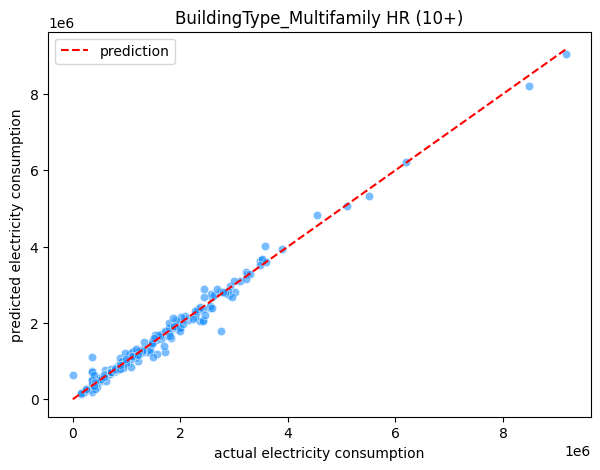

Training model for category: BuildingType_Multifamily LR (1-4)
BuildingType_Multifamily LR (1-4) model R2 score: 0.9609505812346352


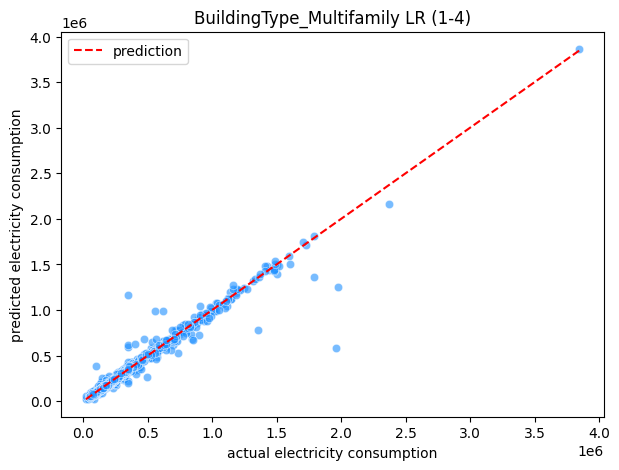

Training model for category: BuildingType_Multifamily MR (5-9)
BuildingType_Multifamily MR (5-9) model R2 score: 0.981739628053939


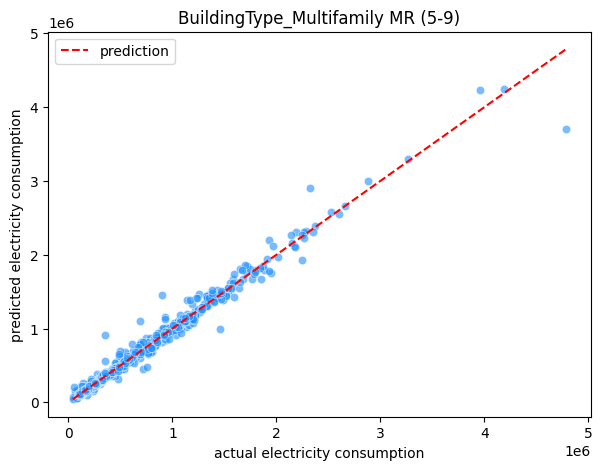

Training model for category: BuildingType_NonResidential
BuildingType_NonResidential model R2 score: 0.8382329048201408


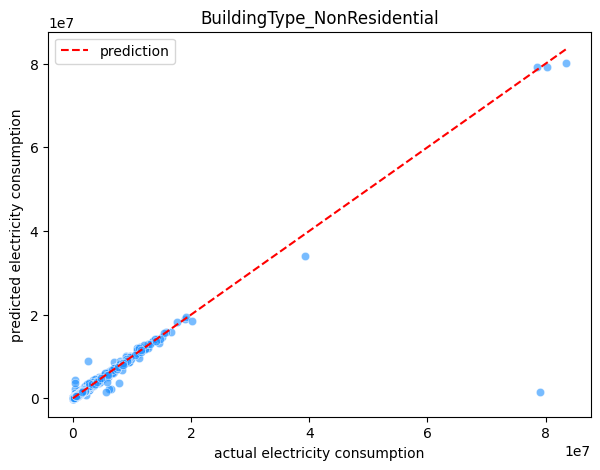

Training model for category: BuildingType_Nonresidential COS
BuildingType_Nonresidential COS model R2 score: 0.9820217142859049


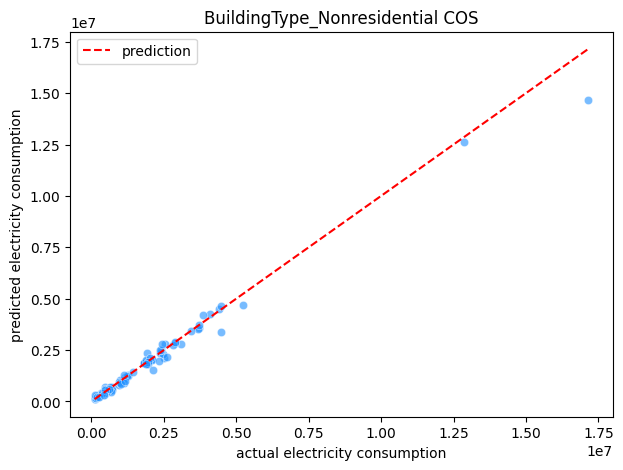

Training model for category: BuildingType_Nonresidential WA
BuildingType_Nonresidential WA model R2 score: 0.9948403062497192


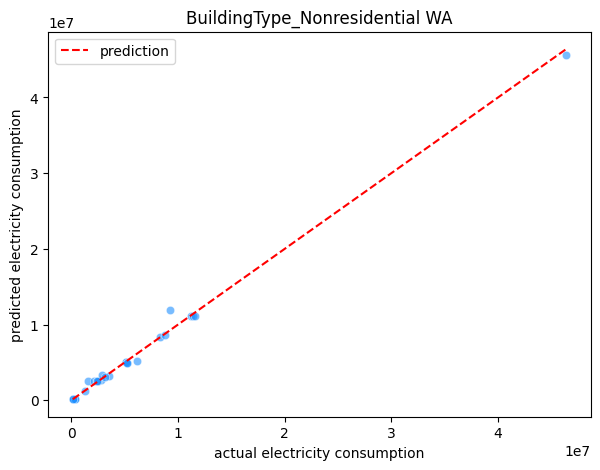

Training model for category: BuildingType_SPS-District K-12
BuildingType_SPS-District K-12 model R2 score: 0.9896670378586228


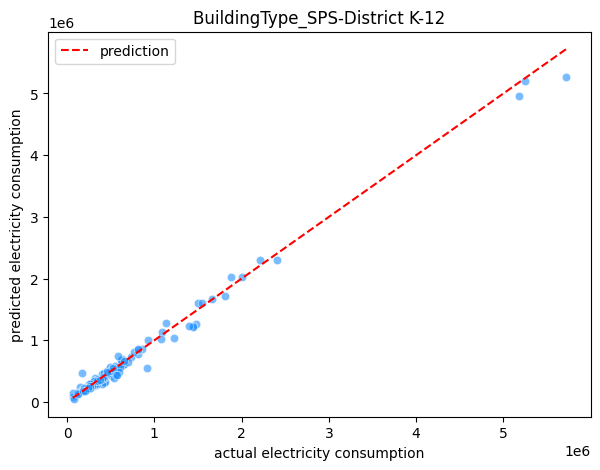

In [7]:
# get one-hot encoded building types
category_columns = [col for col in df.columns if col.startswith("BuildingType_")]

for category in category_columns:
    print(f"Training model for category: {category}")

    df_category = df[df[category] == 1]

    X = df_category.drop(columns=['Electricity(kWh)'] + category_columns)
    y = df_category["Electricity(kWh)"]

    # split dataset into train test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # train with XGBoost
    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_model.fit(X_train, y_train)

    xgb_y_pred = xgb_model.predict(X_test)
    xgb_r2 = r2_score(y_test, xgb_y_pred)

    print(f"{category} model R2 score: {xgb_r2}")

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=y_test, y=xgb_y_pred, color='dodgerblue', alpha=0.6)

    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             linestyle="--", color="red", label="prediction")

    plt.xlabel("actual electricity consumption")
    plt.ylabel("predicted electricity consumption")
    plt.title(f"{category}")
    plt.legend()

    plt.show()

The R2 score is much higher than the previous model. Training separate mdoels per cateogry of building type works better because:

- different building types have unique energy consumption patterns.

- XGBoost struggled when trying to model all types together.

- Now, each model can focus onn the patterns of its specific category.
